In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.shape)

df.info()

df.describe()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    df[col] = df[col].replace(0,np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [5]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\sharm\AppData\Local\Temp\ipykernel_19020\2832450841.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


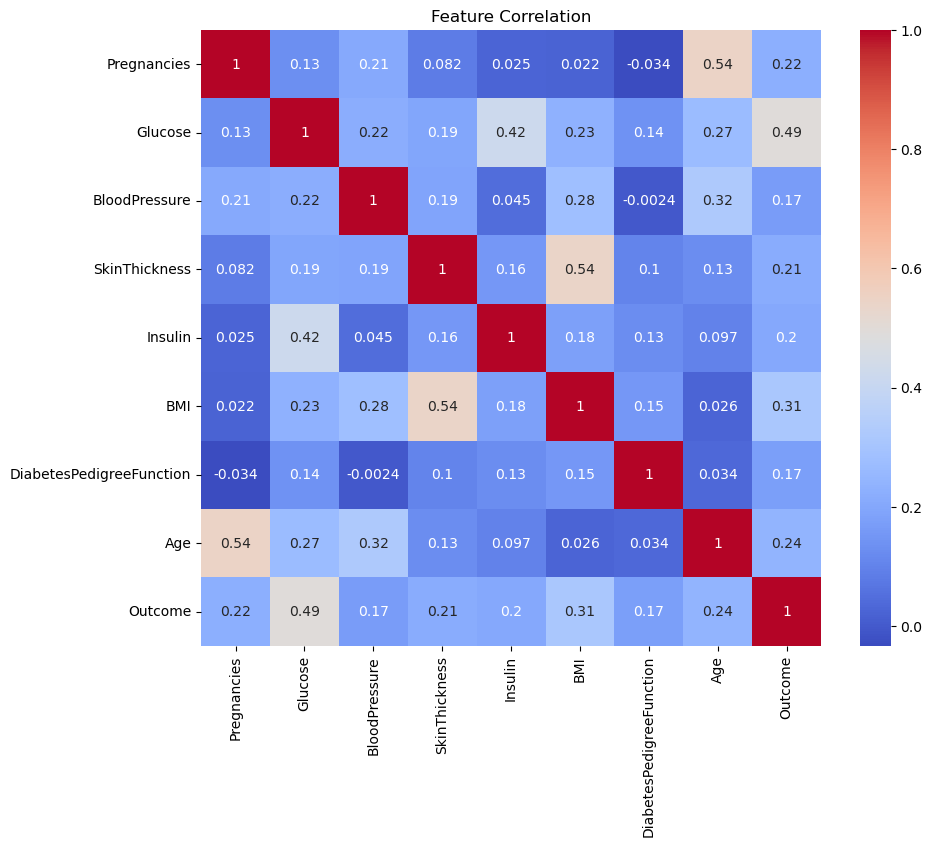

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

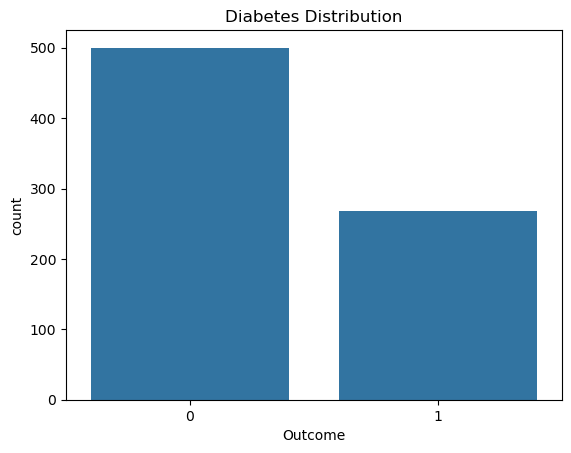

In [7]:
sns.countplot(
    x='Outcome',
    data=df
)

plt.title("Diabetes Distribution")
plt.show()

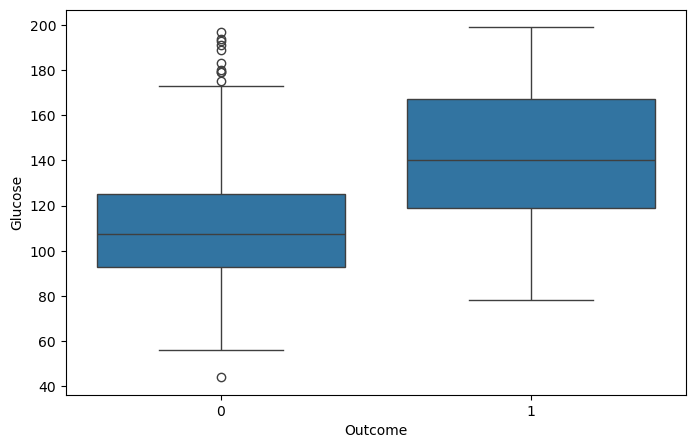

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.show()

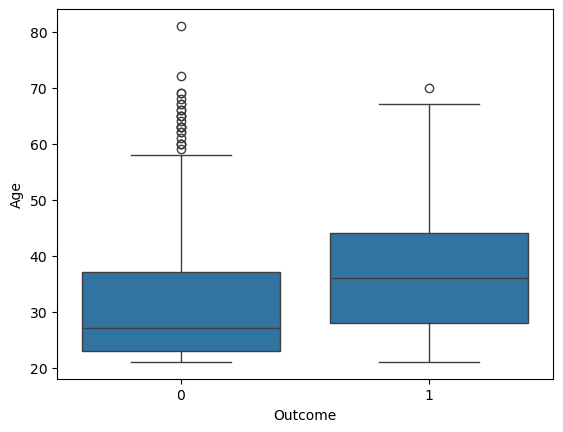

In [9]:
sns.boxplot(
    x='Outcome',
    y='Age',
    data=df
)

plt.show()

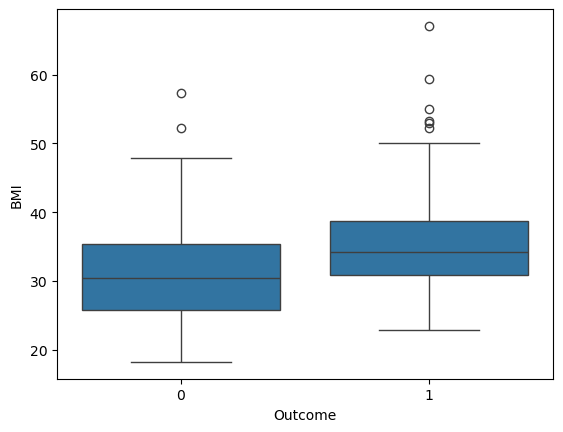

In [10]:
sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.show()

In [11]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,100],
    labels=[1,2,3,4,5]
)

df['AgeGroup'] = df['AgeGroup'].astype(int)

In [12]:
def bmi_category(x):

    if x < 18.5:
        return 0

    elif x < 25:
        return 1

    elif x < 30:
        return 2

    else:
        return 3

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [13]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=160,
    stratify=y
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=2000, random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

In [17]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    auc = roc_auc_score(y_test, pred)

    results.append([name, acc, auc])

results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','ROC_AUC']
)

results_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.837662,0.802593
1,Random Forest,0.876623,0.862407
2,Gradient Boosting,0.844156,0.820370
